In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree 

In [65]:
df = pd.read_csv("../dataset/clean_output.csv")

In [66]:
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [67]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower()

df.columns = df.columns.str.lower()

Data Analysis

In [68]:
df.shape

(11055, 31)

In [69]:
df.columns

Index(['having_ip_address', 'url_length', 'shortining_service',
       'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix',
       'having_sub_domain', 'sslfinal_state', 'domain_registeration_length',
       'favicon', 'port', 'https_token', 'request_url', 'url_of_anchor',
       'links_in_tags', 'sfh', 'submitting_to_email', 'abnormal_url',
       'redirect', 'on_mouseover', 'rightclick', 'popupwidnow', 'iframe',
       'age_of_domain', 'dnsrecord', 'web_traffic', 'page_rank',
       'google_index', 'links_pointing_to_page', 'statistical_report',
       'result'],
      dtype='object')

In [70]:
df.info

<bound method DataFrame.info of        having_ip_address  url_length  shortining_service  having_at_symbol  \
0                     -1           1                   1                 1   
1                      1           1                   1                 1   
2                      1           0                   1                 1   
3                      1           0                   1                 1   
4                      1           0                  -1                 1   
...                  ...         ...                 ...               ...   
11050                  1          -1                   1                -1   
11051                 -1           1                   1                -1   
11052                  1          -1                   1                 1   
11053                 -1          -1                   1                 1   
11054                 -1          -1                   1                 1   

       double_slash_redirecting

In [71]:
df.describe

<bound method NDFrame.describe of        having_ip_address  url_length  shortining_service  having_at_symbol  \
0                     -1           1                   1                 1   
1                      1           1                   1                 1   
2                      1           0                   1                 1   
3                      1           0                   1                 1   
4                      1           0                  -1                 1   
...                  ...         ...                 ...               ...   
11050                  1          -1                   1                -1   
11051                 -1           1                   1                -1   
11052                  1          -1                   1                 1   
11053                 -1          -1                   1                 1   
11054                 -1          -1                   1                 1   

       double_slash_redirecti

In [72]:
df.size

342705

In [73]:
df.corr

<bound method DataFrame.corr of        having_ip_address  url_length  shortining_service  having_at_symbol  \
0                     -1           1                   1                 1   
1                      1           1                   1                 1   
2                      1           0                   1                 1   
3                      1           0                   1                 1   
4                      1           0                  -1                 1   
...                  ...         ...                 ...               ...   
11050                  1          -1                   1                -1   
11051                 -1           1                   1                -1   
11052                  1          -1                   1                 1   
11053                 -1          -1                   1                 1   
11054                 -1          -1                   1                 1   

       double_slash_redirecting

In [74]:
df.isnull().sum()

having_ip_address              0
url_length                     0
shortining_service             0
having_at_symbol               0
double_slash_redirecting       0
prefix_suffix                  0
having_sub_domain              0
sslfinal_state                 0
domain_registeration_length    0
favicon                        0
port                           0
https_token                    0
request_url                    0
url_of_anchor                  0
links_in_tags                  0
sfh                            0
submitting_to_email            0
abnormal_url                   0
redirect                       0
on_mouseover                   0
rightclick                     0
popupwidnow                    0
iframe                         0
age_of_domain                  0
dnsrecord                      0
web_traffic                    0
page_rank                      0
google_index                   0
links_pointing_to_page         0
statistical_report             0
result    

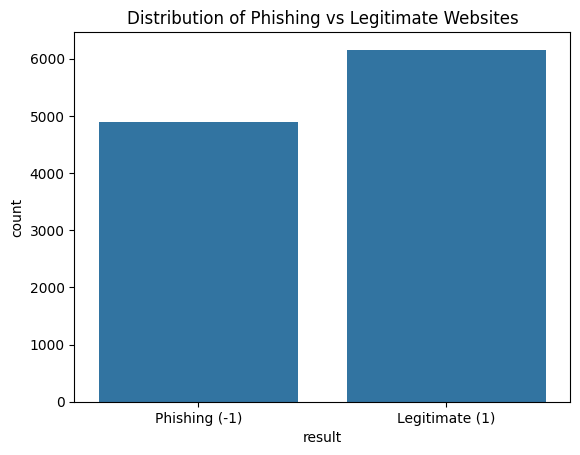

In [75]:
# Target Variable Distribution
sns.countplot(x='result', data=df)
plt.title('Distribution of Phishing vs Legitimate Websites')
plt.xticks(ticks=[0,1], labels=['Phishing (-1)', 'Legitimate (1)'])
plt.show()


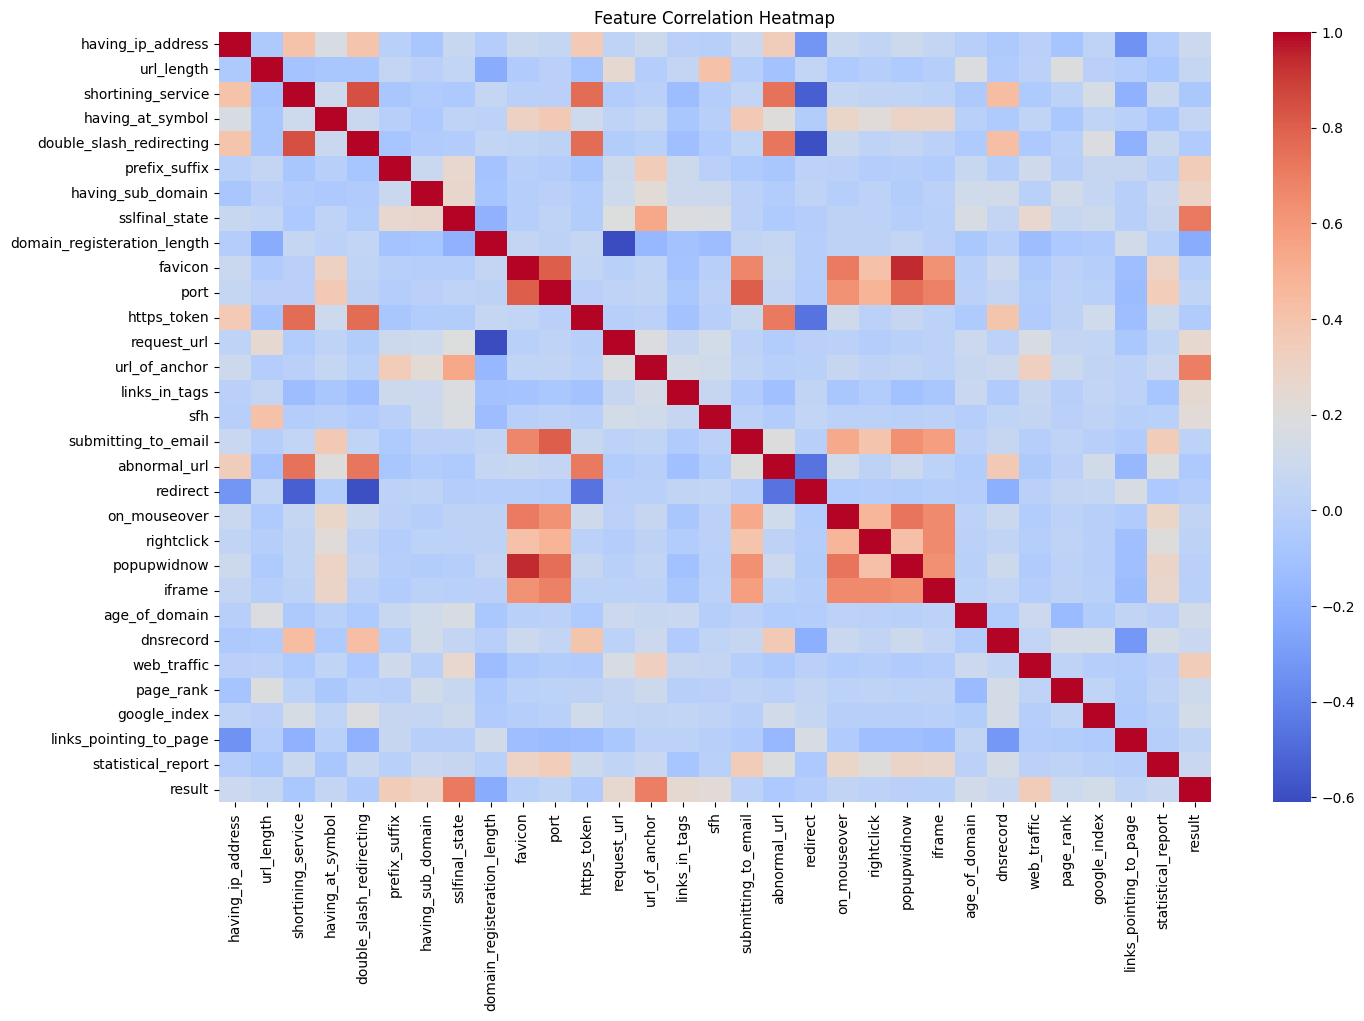

In [76]:
# Correlation Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


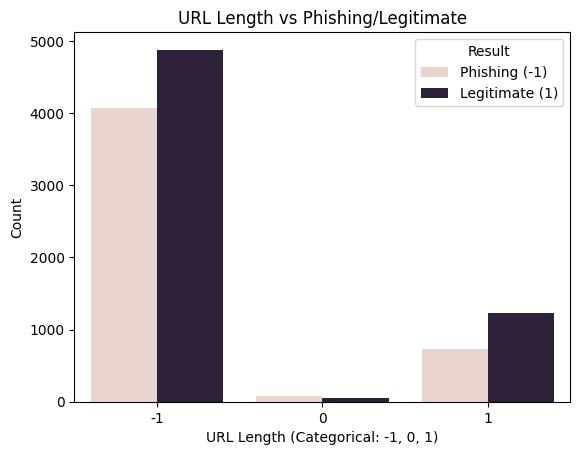

In [77]:
# Feature-wise Distribution & Visualization


sns.countplot(x='url_length', hue='result', data=df)
plt.title('URL Length vs Phishing/Legitimate')
plt.xlabel('URL Length (Categorical: -1, 0, 1)')
plt.ylabel('Count')
plt.legend(title='Result', labels=['Phishing (-1)', 'Legitimate (1)'])
plt.show()


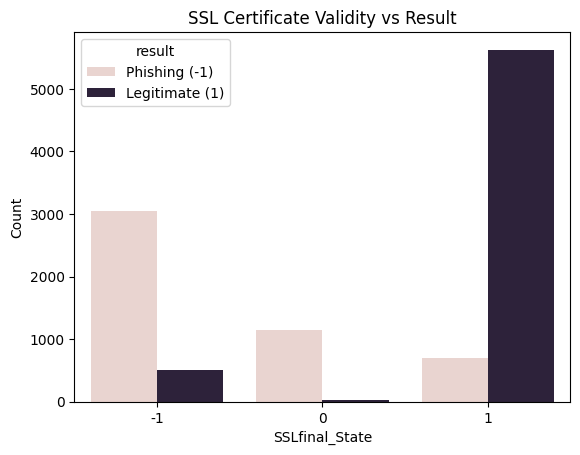

In [78]:
sns.countplot(x='sslfinal_state', hue='result', data=df)
plt.title('SSL Certificate Validity vs Result')
plt.xlabel('SSLfinal_State')
plt.ylabel('Count')
plt.legend(title='result', labels=['Phishing (-1)', 'Legitimate (1)'])
plt.show()


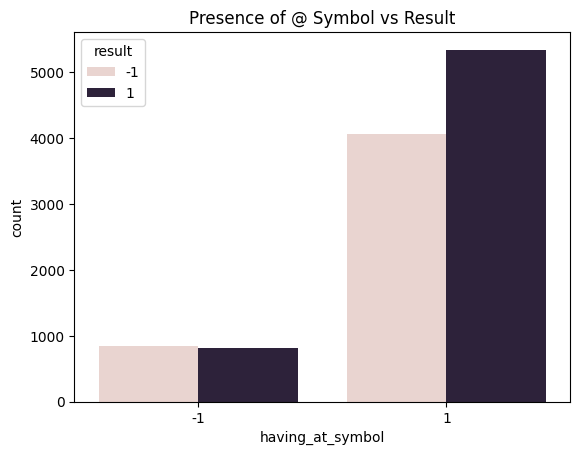

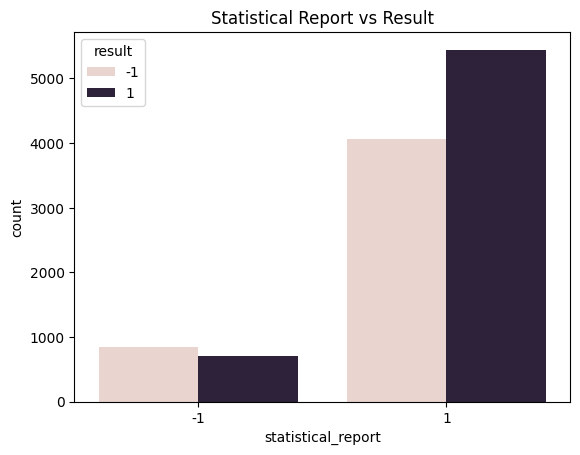

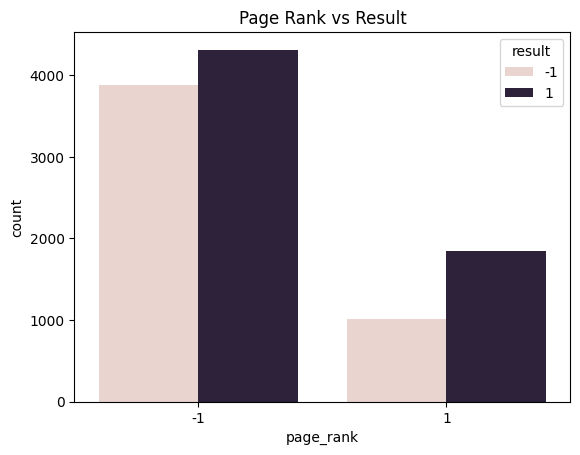

In [79]:
# At symbol presence
sns.countplot(x='having_at_symbol', hue='result', data=df)
plt.title('Presence of @ Symbol vs Result')
plt.show()

# Statistical report
sns.countplot(x='statistical_report', hue='result', data=df)
plt.title('Statistical Report vs Result')
plt.show()

# Page Rank
sns.countplot(x='page_rank', hue='result', data=df)
plt.title('Page Rank vs Result')
plt.show()



In [80]:
# Class Balance Check (Phishing vs Legitimate)

#A. Counts of Each Class
df['result'].value_counts()

#B. Percent Distribution
df['result'].value_counts(normalize=True) * 100

result
 1    55.694256
-1    44.305744
Name: proportion, dtype: float64

Features and Target

In [81]:
x = df.drop('result', axis=1)
y = df['result']

Splitting dataset

In [82]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Model Training

Random Forest

In [83]:
model1 = RandomForestClassifier(random_state=42)
model1.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [84]:
y_pred = model1.predict(x_test)

In [85]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9669832654907282
Confusion Matrix: [[ 909   47]
 [  26 1229]]
Classification Report:
               precision    recall  f1-score   support

          -1       0.97      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [86]:
# Feature Importance

importances = model1.feature_importances_
features = x.columns

# Display top important features
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df.head(10))


                        Feature  Importance
7                sslfinal_state    0.326228
13                url_of_anchor    0.245541
25                  web_traffic    0.069664
6             having_sub_domain    0.064523
14                links_in_tags    0.043273
5                 prefix_suffix    0.037831
15                          sfh    0.020350
12                  request_url    0.019330
28       links_pointing_to_page    0.018834
8   domain_registeration_length    0.017556


Xgboost

In [87]:
y = df["result"]
x = df.drop(columns=["result"])

In [88]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [89]:
xgb_params = {
    'n_estimators': 200,
    'max_depth': 8,
    'learning_rate': 0.5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'verbosity': 1
}

In [90]:
model2 = XGBRegressor(**xgb_params)
model2.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mlogloss',
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.5, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, ...)

In [91]:
y_pred = model2.predict(x_test)
y_pred_labels = np.where(y_pred >= 0, 1, -1)

Accuracy: 0.9678878335594754
Confusion Matrix: [[ 909   47]
 [  24 1231]]
Classification Report:
               precision    recall  f1-score   support

          -1       0.97      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



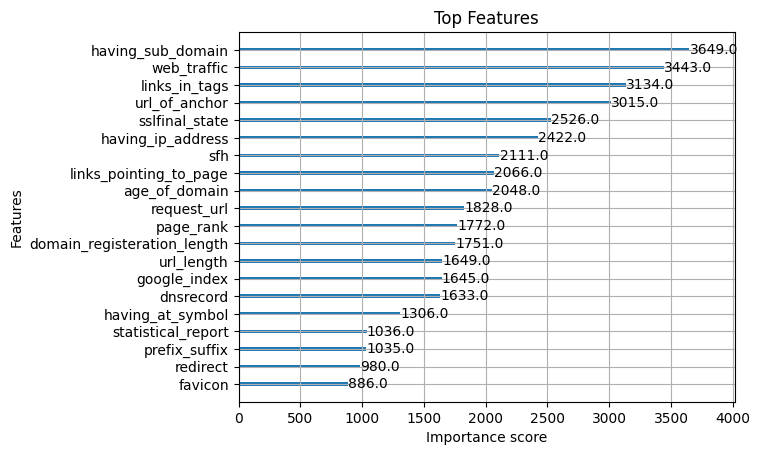

In [92]:
print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred_labels))
print("Classification Report:\n", classification_report(y_test, y_pred_labels))
plot_importance(model2, max_num_features=20)
plt.title("Top Features")
plt.show()

Catboost

In [93]:
model = CatBoostClassifier(verbose=0, iterations=100)
model.fit(x_train, y_train)

In [94]:
y_pred = model.predict(x_test)

In [95]:
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("Attack Type Classification Report:")
print(classification_report(y_test, y_pred))

accuracy_score: 0.9678878335594754
Attack Type Classification Report:
              precision    recall  f1-score   support

          -1       0.98      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211

